In [14]:
import numpy as np
import matplotlib.pyplot as plt

import vertical_profile as vp
import solvers
import constants

Simulating disordered profiles using the TB and EM solvers

Norm v0: 1.0
Norm v1: 1.0
Norm EM: 1.0
<v_0 | z | v_0> = 1.4e+01 (nm)
<v_1 | z | v_1> = 1.4e+01 (nm)
<v_0 | z | v_1> = 0.00098 (nm)


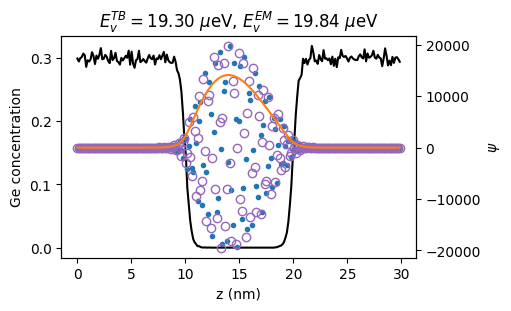

In [15]:
# Create a heterostructure profile
prof = vp.VerticalProfile(interface_type = 'sigmoid')
z_arr = prof.z_arr_nm

# Get a disordered 1D Si concentration array
a_dot_nm = 10
disordered_si = prof.generate_disordered_profile(a_dot_nm)

# Set up a 1D two-band model and solve for the lowest two eigenstates
model = solvers.TwoBand_1D(
    effective_lattice = disordered_si, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.001
)

evals, evecs = model.solve(n_lowest_eigenstates=2)
v0 = evecs[:,0]
v1 = evecs[:,1]

ev = 1e6*model.valley_splitting

# Test the normalization
print(f"Norm v0: {np.sum(np.abs(v0)**2 * model.dz)}")
print(f"Norm v1: {np.sum(np.abs(v1)**2 * model.dz)}")


# Set up a 1D two-band model and solve for the lowest two eigenstates
model_em = solvers.EffectiveMass_1D(
    effective_lattice = disordered_si, 
    bulk_si_concentration = prof.bot_cap_si_concentration, 
    well_si_concentration = prof.well_si_concentration,
    vertical_field = 0.001
)

evals, evecs = model_em.solve(n_lowest_eigenstates=1)
v0_em = evecs[:,0]
ev_em = 1e6*model_em.valley_splitting

print(f"Norm EM: {np.sum(np.abs(v0_em)**2 * model_em.dz)}")


# Print the dipolar matrix elements of z
z00 = model.z00_nm
z11 = model.z11_nm
z01 = model.z01_nm

print(f"<v_0 | z | v_0> = {z00:0.2} (nm)")
print(f"<v_1 | z | v_1> = {z11:0.2} (nm)")
print(f"<v_0 | z | v_1> = {z01:0.2} (nm)")


fig, ax = plt.subplots(figsize=(5,3), layout='constrained')
ax2 = ax.twinx()
ax.plot(z_arr, 1-disordered_si, 'k-', label='Ge concentration')
ax2.plot(z_arr, v0, '.', color='tab:blue', label='TB ground')
ax2.plot(z_arr, v1, 'o', markeredgecolor='tab:purple', markerfacecolor='None', label='TB excited')
ax2.plot(z_arr, v0_em, '-', color='tab:orange', label='EM')
ax.set_xlabel('z (nm)')
ax.set_ylabel('Ge concentration')
ax2.set_ylabel(r'$\psi$')

ax.set_title(r'$E_v^{TB} = $' + rf'{ev:.2f} $\mu$eV, ' + r'$E_v^{EM} = $' + rf'{ev_em:.2f} $\mu$eV')
plt.show()

Valley splitting distributions for sharp and sigmoidal quantum wells

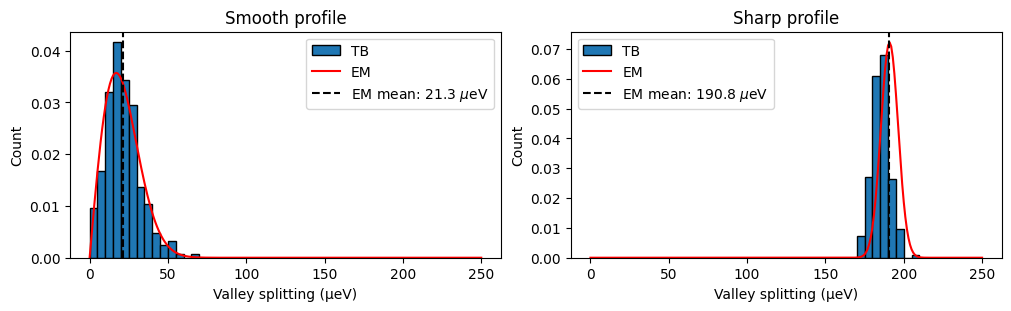

In [16]:
# Compute valley splitting for many disorder realizations of smooth and sharp heterostructure profiles

prof_smooth = vp.VerticalProfile(interface_type = 'sigmoid')
prof_sharp = vp.VerticalProfile(interface_type = 'sharp')

vertical_field = 0.001

n_realizations = 250
valley_splittings_smooth = np.zeros(n_realizations)
valley_splittings_sharp = np.zeros_like(valley_splittings_smooth)

for i in range(n_realizations):

    # Data generation for smooth profile
    disordered_si = prof_smooth.generate_disordered_profile(a_dot_nm)
    model = solvers.TwoBand_1D(
        effective_lattice = disordered_si, 
        bulk_si_concentration = prof_smooth.bot_cap_si_concentration, 
        well_si_concentration = prof_smooth.well_si_concentration,        
        vertical_field = vertical_field,
        sparse = False
    )
    valley_splittings_smooth[i] = 1e6*model.valley_splitting


    # Data generation for sharp profile
    disordered_si = prof_sharp.generate_disordered_profile(a_dot_nm)
    model = solvers.TwoBand_1D(
        effective_lattice = disordered_si, 
        bulk_si_concentration = prof_sharp.bot_cap_si_concentration, 
        well_si_concentration = prof_sharp.well_si_concentration,        
        vertical_field = vertical_field,
        sparse = False
    )
    valley_splittings_sharp[i] = 1e6*model.valley_splitting


# Smooth and sharp effective mass solvers.
# Note: we use the un-disordered Si concentrations for these.
model_em_smooth = solvers.EffectiveMass_1D(
    effective_lattice = prof_smooth.si_concentrations, 
    bulk_si_concentration = prof_smooth.bot_cap_si_concentration, 
    well_si_concentration = prof_smooth.well_si_concentration,
    vertical_field = vertical_field,
    sparse = False
)

model_em_sharp = solvers.EffectiveMass_1D(
    effective_lattice = prof_sharp.si_concentrations, 
    bulk_si_concentration = prof_sharp.bot_cap_si_concentration, 
    well_si_concentration = prof_sharp.well_si_concentration,
    vertical_field = vertical_field,
    sparse = False
)


ev_arr = np.linspace(0, 250, 251)
sigma_delta_smooth = model_em_smooth.sigma_delta(a_dot_nm)
mean_Ev_smooth = np.sqrt(np.pi) * sigma_delta_smooth

pdf_smooth = model_em_smooth.valley_splitting_pdf(1e-6*ev_arr, dot_size_nm=a_dot_nm)

delta_0_sharp = model_em_sharp.inter_valley_coupling
mean_Ev_sharp = 2 * abs(delta_0_sharp)
pdf_sharp = model_em_sharp.valley_splitting_pdf(1e-6*ev_arr, dot_size_nm=a_dot_nm)


bins = np.linspace(0, 250, 51)

fig, ax = plt.subplots(1, 2, figsize=(10,3), layout='constrained')
ax[0].hist(valley_splittings_smooth, color='tab:blue', edgecolor='k', density=True, label='TB', bins=bins)
ax[0].plot(ev_arr, pdf_smooth * 1e-6, 'r-', label='EM')
ax[0].axvline(mean_Ev_smooth * 1e6, color='k', linestyle='--', label=r'EM mean: ' + rf'{mean_Ev_smooth*1e6:.1f} $\mu$eV')
ax[0].set_xlabel('Valley splitting (μeV)')
ax[0].set_ylabel('Count')
ax[0].set_title('Smooth profile')
ax[0].legend()

ax[1].hist(valley_splittings_sharp, color='tab:blue', edgecolor='k', density=True, label='TB', bins=bins)
ax[1].plot(ev_arr, pdf_sharp * 1e-6, 'r-', label='EM')
ax[1].axvline(mean_Ev_sharp * 1e6, color='k', linestyle='--', label=r'EM mean: ' + rf'{mean_Ev_sharp*1e6:.1f} $\mu$eV')
ax[1].set_xlabel('Valley splitting (μeV)')
ax[1].set_ylabel('Count')
ax[1].set_title('Sharp profile')
ax[1].legend()

plt.show()

Variable Ge concentration in the quantum well

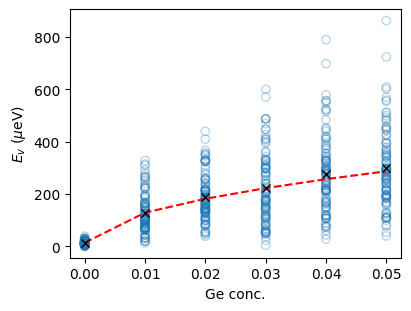

In [17]:
ge_conc_arr = np.linspace(0, 0.05, 6)

mean_ev_EM = np.zeros_like(ge_conc_arr)
mean_ev_TB = np.zeros_like(ge_conc_arr)

vertical_field = 0.001
n_realizations = 100
a_dot_nm = 15


fig, ax = plt.subplots(figsize=(4,3), layout='constrained')

for j, ge_conc in enumerate(ge_conc_arr):
    prof_smooth = vp.VerticalProfile(interface_type = 'sigmoid', well_si_concentration=1-ge_conc)

    valley_splittings_tb = np.zeros(n_realizations)

    for i in range(n_realizations):

        # Data generation for smooth profile
        disordered_si = prof_smooth.generate_disordered_profile(a_dot_nm)
        model = solvers.TwoBand_1D(
            effective_lattice = disordered_si, 
            bulk_si_concentration = prof_smooth.bot_cap_si_concentration, 
            well_si_concentration = prof_smooth.well_si_concentration,        
            vertical_field = vertical_field,
            sparse = False
        )
        valley_splittings_tb[i] = 1e6*model.valley_splitting

    ax.scatter(ge_conc * np.ones_like(valley_splittings_tb), valley_splittings_tb, marker='o', facecolors='None', edgecolors='tab:blue', alpha=0.3 )
    mean_ev_TB[j] = np.mean(valley_splittings_tb)

    model_EM = solvers.EffectiveMass_1D(
        effective_lattice = prof_smooth.si_concentrations, 
        bulk_si_concentration = prof_smooth.bot_cap_si_concentration, 
        well_si_concentration = prof_smooth.well_si_concentration,        
        vertical_field = vertical_field,
        sparse = False
    )
    sd = 1e6 * model_EM.sigma_delta(dot_size_nm=a_dot_nm)
    mean_ev_EM[j] = np.sqrt(np.pi) * sd

ax.plot(ge_conc_arr, mean_ev_EM, 'r--')
ax.plot(ge_conc_arr, mean_ev_TB, 'kx')

ax.set_xlabel('Ge conc.')
ax.set_ylabel(r'$E_v$ ($\mu$eV)')
plt.show()
